### Segmentation Analysis

Segmentation analysis is done to analyze the customers basis, where we try to what kind of customers are in the organization, this will be fully useful identify and target different customers for marketing and promotions, and even build better relationship with customers.

In [1]:
# Loading python libraries
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

#### Loading the dataset

In [2]:
data = pd.read_csv("../data/raw/churn_data.csv")
data.head()

,Unnamed: 0,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [3]:
data.set_index("CustomerID", inplace=True)

In [4]:
data.dropna(inplace=True) # Drop rows with missing values for clustering

#### RFM Analysis

In [5]:
# Let's first to do RFM analysis to see how the segmentation works.
# R - Recency: How recently a customer has made a purchase or engaged with the service. Last Interaction
# F - Frequency: How often a customer makes a purchase or engages with the service. Usage Frequency
# M - Monetary Value: How much money a customer spends on the service. Total Spend
seg_data = data[["Last Interaction", "Usage Frequency", "Total Spend"]]
seg_data.shape

(440832, 3)

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(seg_data)

307026.189029063


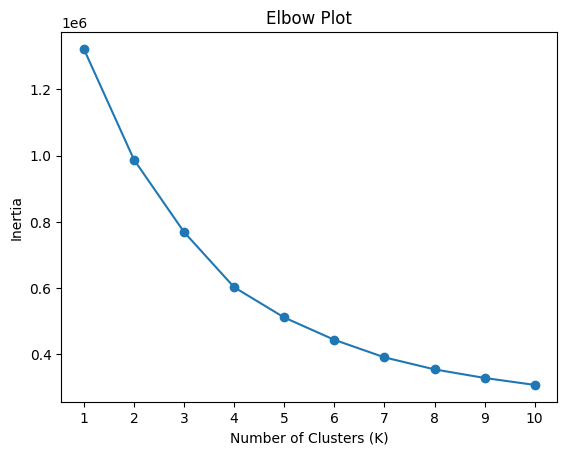

In [7]:
# Creating a Elbow plot to find the optimal number of clusters
inertia = [] 

# create a loop see which is best k value for our data
for k in range(1,11):
    model = KMeans(n_clusters=k, n_init=10, random_state=42) # KMeans models to run each K value.
    model.fit(X_scaled) # Fit the model to the data
    inertia.append(model.inertia_) # Append the inertia to the list


print(min(inertia))
plt.plot(range(1,11), inertia, marker="o")
plt.title("Elbow Plot")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(1,11))
plt.show()

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)
RFM_data = data.copy()
RFM_data["Cluster"] = kmeans.labels_

In [9]:
RFM_data["Cluster"].value_counts()

Cluster
3    120086
1    113185
0    111420
2     96141
Name: count, dtype: int64

In [10]:
RFM_data.columns

Index(['Unnamed: 0', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn',
       'Cluster'],
      dtype='str')

In [11]:
RFM_data.groupby("Cluster")[["Last Interaction", "Usage Frequency", "Total Spend",'Payment Delay','Support Calls', 'Churn' ]].mean()

,Last Interaction,Usage Frequency,Total Spend,Payment Delay,Support Calls,Churn
Cluster,,,,,,
0,24.489248,16.151319,738.001919,12.862547,3.518614,0.541339
1,9.076503,7.643195,727.125277,12.351495,3.157265,0.429138
2,16.312645,15.347230,276.501240,14.897130,4.942314,0.981725
3,8.822011,23.552088,727.192917,12.094091,3.034434,0.389113


Customer segmentation reveals four distinct behavioral groups:

1. Low Value, High Risk Customers exhibit extremely high churn rates (~98%), driven by high payment delays and frequent support interactions.

2. Highly Engaged High-Value Customers show the lowest churn rates, characterized by high usage, strong spending, and low service friction.

3. Passive High-Value Customers maintain high spending but low engagement, indicating potential future churn risk despite current stability.

4. High-Value but Disengaging Customers show elevated churn despite strong spending, suggesting that reduced interaction is an early warning signal of attrition.

### Behavioural clustering

In [12]:
# Let's do the Behavioural Segmentation using Support Calls and Payment Delay
seg_data2 = data[["Total Spend", "Usage Frequency", "Payment Delay", "Support Calls"]]
seg_data2.head()

,Total Spend,Usage Frequency,Payment Delay,Support Calls
CustomerID,,,,
2.0,932.0,14.0,18.0,5.0
3.0,557.0,1.0,8.0,10.0
4.0,185.0,4.0,18.0,6.0
5.0,396.0,21.0,7.0,7.0
6.0,617.0,20.0,8.0,5.0


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(seg_data2)

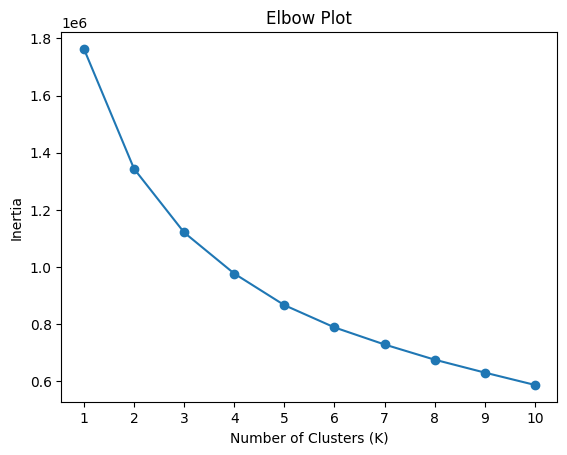

In [14]:
# Creating a Elbow plot to find the optimal number of clusters
inertia = [] 

# create a loop see which is best k value for our data
for k in range(1,11):
    model = KMeans(n_clusters=k, n_init=10, random_state=42) # KMeans models to run each K value.
    model.fit(X_scaled) # Fit the model to the data
    inertia.append(model.inertia_) # Append the inertia to the list


# print(min(inertia))
plt.plot(range(1,11), inertia, marker="o")
plt.title("Elbow Plot")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(1,11))
plt.show()

In [15]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)
behave_data = data.copy()
behave_data["Cluster"] = kmeans.labels_

In [16]:
behave_data.head()

,Unnamed: 0,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Cluster
CustomerID,,,,,,,,,,,,,
2.0,0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0,0
3.0,1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0,0
4.0,2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0,2
5.0,3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0,2
6.0,4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0,3


In [17]:
behave_data["Cluster"].value_counts()

Cluster
3    141178
1    129032
2     96188
0     74434
Name: count, dtype: int64

In [18]:
behave_data.groupby("Cluster")[["Last Interaction", "Usage Frequency", "Total Spend",'Payment Delay','Support Calls', 'Churn' ]].mean()

,Last Interaction,Usage Frequency,Total Spend,Payment Delay,Support Calls,Churn
Cluster,,,,,,
0,15.470941,15.471384,725.757608,17.249160,7.863100,0.990434
1,13.895166,7.982260,728.864904,10.769088,1.874411,0.319138
2,15.443912,15.564717,280.734134,16.010563,5.207354,0.990851
3,13.838034,23.302115,732.164004,10.640468,1.848199,0.281843


In [19]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_scaled)
behave_data = data.copy()
behave_data["Cluster"] = kmeans.labels_

In [20]:
behave_data["Cluster"].value_counts()

Cluster
2    110528
3     99908
4     84632
1     82031
0     63733
Name: count, dtype: int64

In [21]:
behave_data.groupby("Cluster")[["Last Interaction", "Usage Frequency", "Total Spend",'Payment Delay','Support Calls', 'Churn' ]].mean()

,Last Interaction,Usage Frequency,Total Spend,Payment Delay,Support Calls,Churn
Cluster,,,,,,
0,15.469396,14.651060,728.691170,16.436242,8.241460,0.996956
1,14.371920,20.110019,695.137445,20.577257,2.003791,0.511624
2,13.838539,7.336955,726.035585,9.666564,1.892670,0.295572
3,13.804240,23.109090,722.159150,6.229912,2.049666,0.274473
4,15.479677,14.950917,266.747933,15.234864,5.734876,0.997259


In [22]:
# Let's do the Behavioural Segmentation using Support Calls and Payment Delay
seg_data3 = data[["Payment Delay", "Support Calls"]]
seg_data3.head()

,Payment Delay,Support Calls
CustomerID,,
2.0,18.0,5.0
3.0,8.0,10.0
4.0,18.0,6.0
5.0,7.0,7.0
6.0,8.0,5.0


In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(seg_data3)

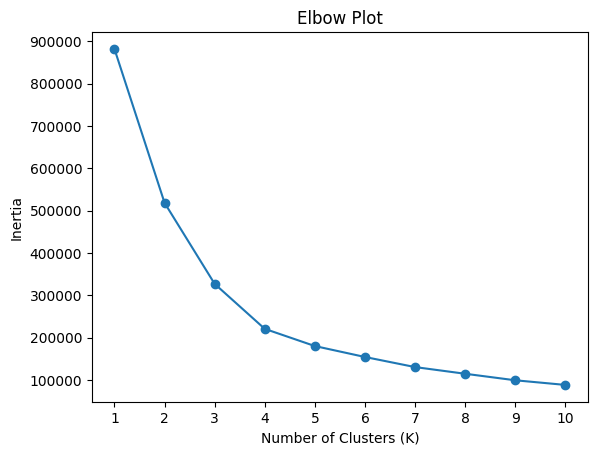

In [24]:
# Creating a Elbow plot to find the optimal number of clusters
inertia = [] 

# create a loop see which is best k value for our data
for k in range(1,11):
    model = KMeans(n_clusters=k, n_init=10, random_state=42) # KMeans models to run each K value.
    model.fit(X_scaled) # Fit the model to the data
    inertia.append(model.inertia_) # Append the inertia to the list


# print(min(inertia))
plt.plot(range(1,11), inertia, marker="o")
plt.title("Elbow Plot")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(1,11))
plt.show()

In [25]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)
behave_data = data.copy()
behave_data["Cluster"] = kmeans.labels_

In [26]:
behave_data.groupby("Cluster")[["Last Interaction", "Usage Frequency", "Total Spend",'Payment Delay','Support Calls', 'Churn' ]].mean()

,Last Interaction,Usage Frequency,Total Spend,Payment Delay,Support Calls,Churn
Cluster,,,,,,
0,15.475207,15.574278,552.716096,7.025259,7.470830,0.986165
1,14.277102,15.852018,649.685145,18.780067,1.801078,0.471703
2,13.767450,16.017971,687.475764,6.012295,1.695317,0.269116
3,15.473750,15.486702,550.920356,22.894484,7.466697,0.997499


- Cluster 3 → Critical Risk Customers
- Cluster 0 → Service Issue Customers
- Cluster 1 → Payment Risk Customers
- Cluster 2 → Stable Customers

#### Mix Both to see

In [27]:
# Let's do the Behavioural Segmentation using Support Calls and Payment Delay
seg_data4 = data[["Total Spend", "Usage Frequency", "Last Interaction", "Payment Delay", "Support Calls"]]
seg_data4.head()

,Total Spend,Usage Frequency,Last Interaction,Payment Delay,Support Calls
CustomerID,,,,,
2.0,932.0,14.0,17.0,18.0,5.0
3.0,557.0,1.0,6.0,8.0,10.0
4.0,185.0,4.0,3.0,18.0,6.0
5.0,396.0,21.0,29.0,7.0,7.0
6.0,617.0,20.0,20.0,8.0,5.0


In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(seg_data4)

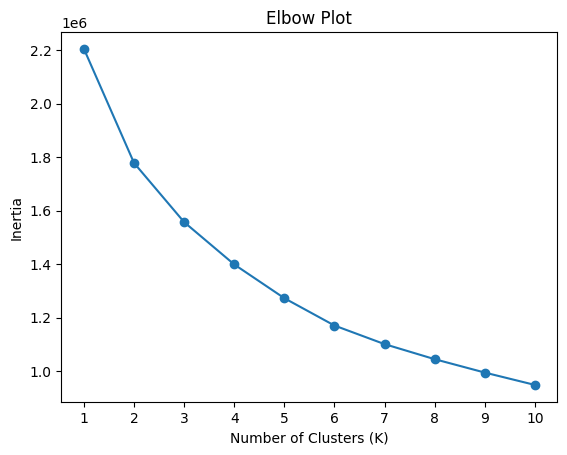

In [29]:
# Creating a Elbow plot to find the optimal number of clusters
inertia = [] 

# create a loop see which is best k value for our data
for k in range(1,11):
    model = KMeans(n_clusters=k, n_init=10, random_state=42) # KMeans models to run each K value.
    model.fit(X_scaled) # Fit the model to the data
    inertia.append(model.inertia_) # Append the inertia to the list


# print(min(inertia))
plt.plot(range(1,11), inertia, marker="o")
plt.title("Elbow Plot")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(1,11))
plt.show()

In [30]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_scaled)
behave_data = data.copy()
behave_data["Cluster"] = kmeans.labels_

In [31]:
behave_data.groupby("Cluster")[["Last Interaction", "Usage Frequency", "Total Spend",'Payment Delay','Support Calls', 'Churn' ]].mean()

,Last Interaction,Usage Frequency,Total Spend,Payment Delay,Support Calls,Churn
Cluster,,,,,,
0,16.022429,15.370669,730.974150,17.659488,8.022066,0.995176
1,8.974619,7.696908,720.438508,10.788915,1.980996,0.313755
2,15.633397,15.434689,272.543695,16.213674,5.571762,0.996523
3,24.571603,16.320837,709.635959,11.284925,2.020271,0.431539
4,8.701224,23.548582,724.501125,10.638873,1.958167,0.275633
